In [ ]:
import sys
sys.path.append('..')

# Clustering Model Development
import pandas as pd
from src.preprocessing import scale_features, encode_categorical
from src.feature_engineering import apply_pca
from src.clustering import find_optimal_clusters, train_kmeans
from src.evaluation import evaluate_clusters
from src.visualization import plot_elbow, plot_silhouette

In [13]:
#Loading data
data = pd.read_csv('../Data/cleaned_data.csv')

In [14]:
# Preprocessing
data_encoded = encode_categorical(data)
data_scaled = scale_features(data_encoded)


In [15]:
# Applying PCA
data_pca = apply_pca(data_scaled, n_components=3)

Explained variance ratio: [0.23621651 0.13083443 0.09988185]


Silhouette score for k=2: 0.2565
Silhouette score for k=3: 0.1636
Silhouette score for k=4: 0.2034
Silhouette score for k=5: 0.2047
Silhouette score for k=6: 0.2069
Silhouette score for k=7: 0.2027
Silhouette score for k=8: 0.2059
Silhouette score for k=9: 0.2062
Silhouette score for k=10: 0.1501


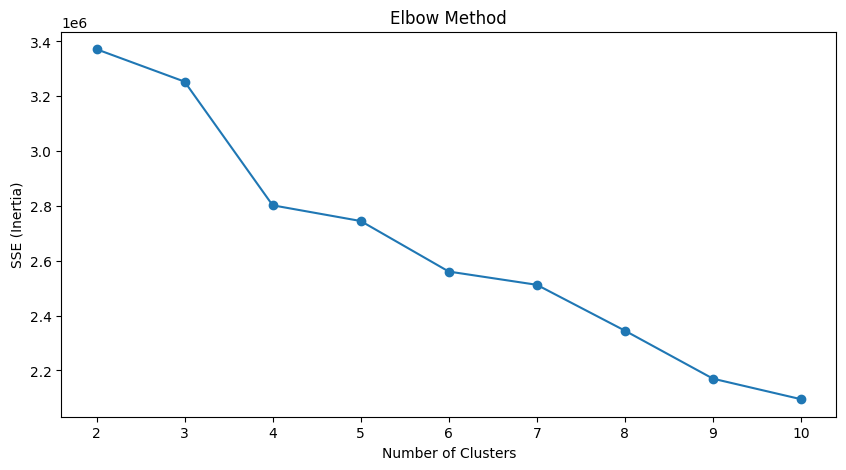

([3371534.62345161,
  3253307.0446804743,
  2802382.5565232765,
  2745054.45246169,
  2560769.476879576,
  2512405.9232437583,
  2345170.282795079,
  2170138.3455966422,
  2095210.2158371345],
 [0.2564670133469915,
  0.16355213625627188,
  0.2033810710464964,
  0.20469774408329078,
  0.20694736107438802,
  0.20266193697011622,
  0.20586487592611197,
  0.20620309473338436,
  0.15013835879607093])

In [16]:
#Finding optimal number of clusters
find_optimal_clusters(data_scaled, k_range=range(2, 11))

In [17]:
# Training K-Means with optimal k=5
kmeans_model = train_kmeans(data_scaled, n_clusters=5)
data['Cluster'] = kmeans_model.labels_
data.to_csv('../Data/cleaned_data2.csv', index=False)

In [18]:
evaluate_clusters(data_scaled, kmeans_model.labels_)

Silhouette Score: 0.2047


0.20469774408329078

In [19]:
#Saving model
import joblib
joblib.dump(kmeans_model, '../models/kmeans_model.pkl')

['../models/kmeans_model.pkl']